## https://towardsdatascience.com/advanced-time-series-forecasting-with-sktime-af8eabc76173/

## https://www.delftstack.com/howto/python/auto-arima-python/

## https://www.statsmodels.org/dev/examples/index.html#time-series-analysis

# Introduction to sktime for Time Series Analysis

## Overview

`sktime` is a unified framework for machine learning with time series. It provides:
- **scikit-learn compatible API** for time series tasks
- **Modular architecture** for forecasting, classification, regression, and clustering
- **State-of-the-art algorithms** including deep learning and statistical methods
- **Composable transformers** for feature engineering and preprocessing

### Key Use Cases in Finance
- Stock price forecasting
- Portfolio risk modeling
- Algorithmic trading signals
- Credit default prediction
- Market regime detection

### Installation
```bash
pip install sktime
pip install sktime[all_extras]  # For all dependencies
```

In [1]:
# Import core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sktime.datasets import load_airline
from sktime.forecasting.base import ForecastingHorizon
from sktime.split import temporal_train_test_split

# Set style
plt.style.use('seaborn-v0_8-darkgrid')

---
## 1. Univariate Time Series

Univariate time series involve a single variable observed over time. Common in finance for individual asset prices, trading volumes, or economic indicators.

### 1.1 Data Loading and Exploration

Data type: <class 'pandas.core.series.Series'>
Shape: (144,)

First few values:
Period
1949-01    112.0
1949-02    118.0
1949-03    132.0
1949-04    129.0
1949-05    121.0
Freq: M, Name: Number of airline passengers, dtype: float64


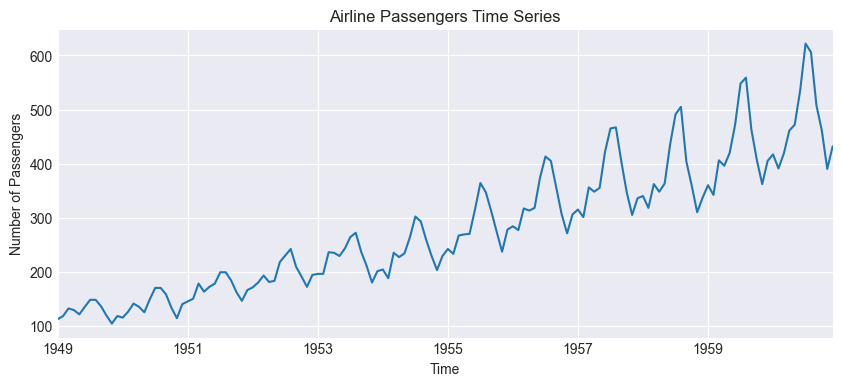

In [2]:
# Load example dataset (airline passengers)
y = load_airline()

print(f"Data type: {type(y)}")
print(f"Shape: {y.shape}")
print(f"\nFirst few values:\n{y.head()}")

# Visualize
y.plot(figsize=(10, 4))
plt.title('Airline Passengers Time Series')
plt.ylabel('Number of Passengers')
plt.xlabel('Time')
plt.show()

### 1.2 Train-Test Split

Train size: 120, Test size: 24


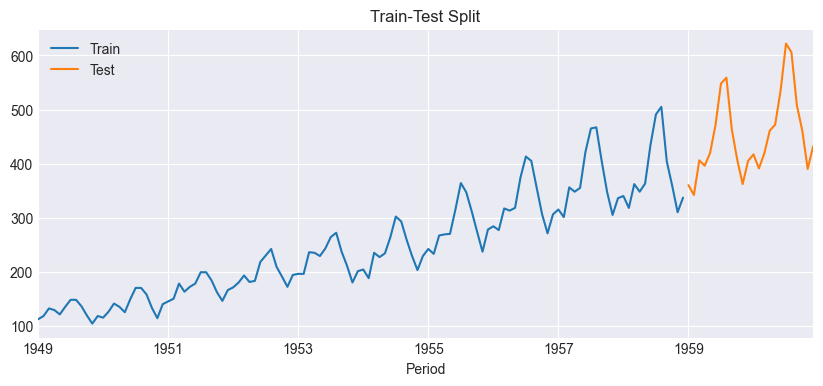

In [3]:
# Temporal split (no random shuffling for time series)
y_train, y_test = temporal_train_test_split(y, test_size=24)

print(f"Train size: {len(y_train)}, Test size: {len(y_test)}")

# Visualize split
fig, ax = plt.subplots(figsize=(10, 4))
y_train.plot(ax=ax, label='Train')
y_test.plot(ax=ax, label='Test')
plt.legend()
plt.title('Train-Test Split')
plt.show()

### 1.3 Forecasting Models

#### Naive Baseline

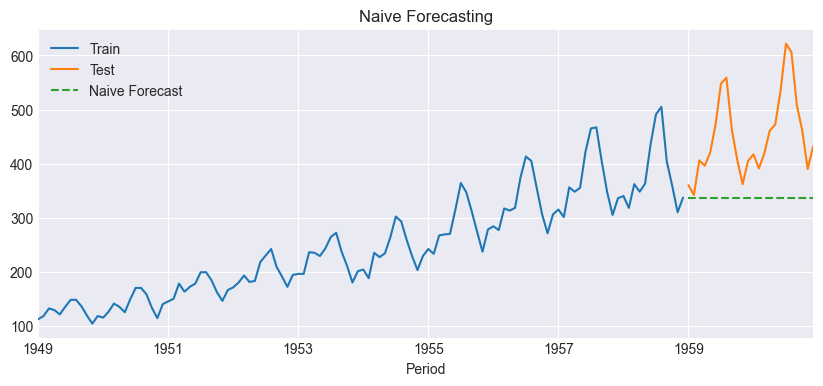

In [4]:
from sktime.forecasting.naive import NaiveForecaster

# Naive forecaster (last value)
forecaster_naive = NaiveForecaster(strategy="last")
forecaster_naive.fit(y_train)
fh = ForecastingHorizon(y_test.index, is_relative=False)
y_pred_naive = forecaster_naive.predict(fh)

# Plot
fig, ax = plt.subplots(figsize=(10, 4))
y_train.plot(ax=ax, label='Train')
y_test.plot(ax=ax, label='Test')
y_pred_naive.plot(ax=ax, label='Naive Forecast', linestyle='--')
plt.legend()
plt.title('Naive Forecasting')
plt.show()

#### Exponential Smoothing

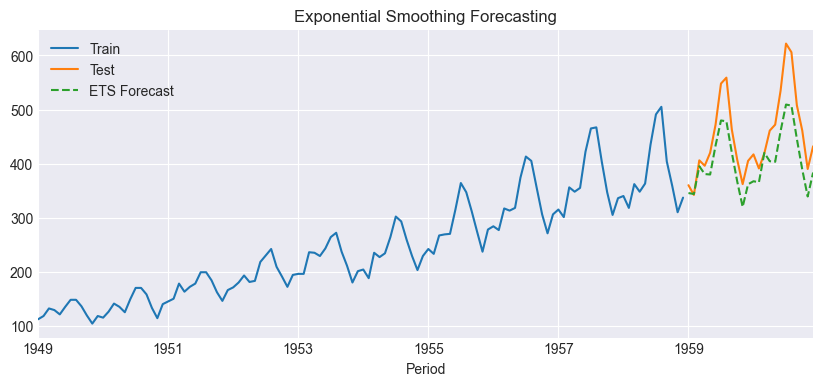

In [5]:
from sktime.forecasting.ets import AutoETS

# Auto ETS (Exponential Smoothing)
forecaster_ets = AutoETS(auto=True, sp=12)
forecaster_ets.fit(y_train)
y_pred_ets = forecaster_ets.predict(fh)

# Plot
fig, ax = plt.subplots(figsize=(10, 4))
y_train.plot(ax=ax, label='Train')
y_test.plot(ax=ax, label='Test')
y_pred_ets.plot(ax=ax, label='ETS Forecast', linestyle='--')
plt.legend()
plt.title('Exponential Smoothing Forecasting')
plt.show()

# ARIMA Model

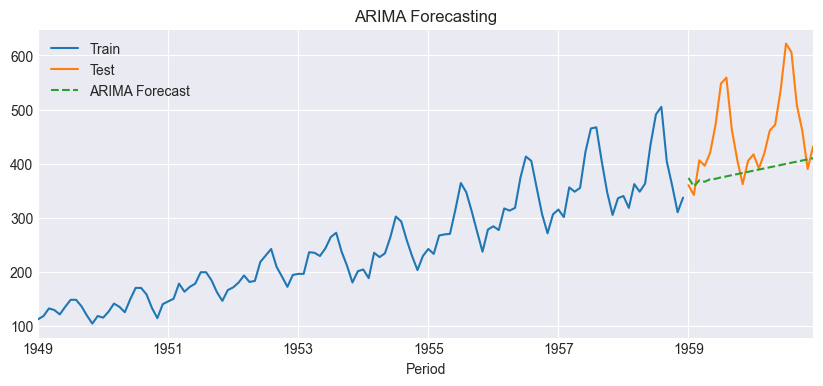

In [6]:
from sktime.forecasting.arima import ARIMA

# ARIMA model
forecaster_arima = ARIMA(order=(1, 1, 1))
forecaster_arima.fit(y_train)
y_pred_arima = forecaster_arima.predict(fh)

# Plot
fig, ax = plt.subplots(figsize=(10, 4))
y_train.plot(ax=ax, label='Train')
y_test.plot(ax=ax, label='Test')
y_pred_arima.plot(ax=ax, label='ARIMA Forecast', linestyle='--')
plt.legend()
plt.title('ARIMA Forecasting')
plt.show()

# SARIMAX model

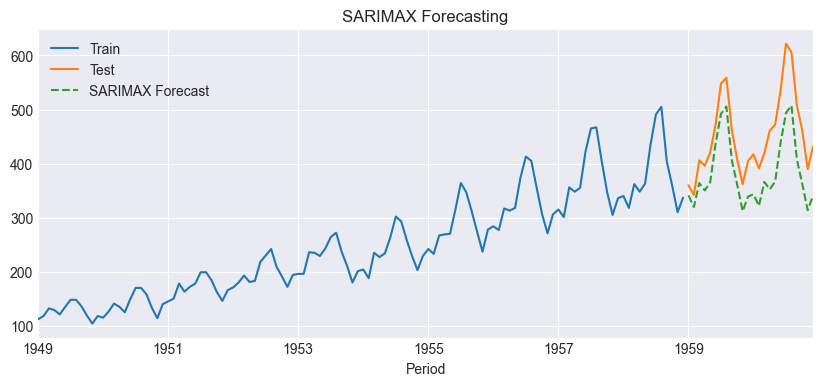

In [7]:
from sktime.forecasting.sarimax import SARIMAX

# ARIMA model
forecaster_sarimax = SARIMAX(order=(1, 1, 2), seasonal_order=(0, 1, 1, 12))
forecaster_sarimax.fit(y_train)
y_pred_sarimax = forecaster_sarimax.predict(fh)

# Plot
fig, ax = plt.subplots(figsize=(10, 4))
y_train.plot(ax=ax, label='Train')
y_test.plot(ax=ax, label='Test')
y_pred_sarimax.plot(ax=ax, label='SARIMAX Forecast', linestyle='--')
plt.legend()
plt.title('SARIMAX Forecasting')
plt.show()

### 1.4 Model Evaluation

In [8]:
from sktime.performance_metrics.forecasting import mean_absolute_percentage_error, mean_squared_error

# Calculate metrics
models = {
    'Naive': y_pred_naive,
    'ARIMA': y_pred_arima,
    'ETS': y_pred_ets,
    'SARIMAX': y_pred_sarimax
}

results = []
for name, pred in models.items():
    mape = mean_absolute_percentage_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    results.append({'Model': name, 'MAPE': mape, 'RMSE': rmse})

results_df = pd.DataFrame(results)
results_df.round(2)

,Model,MAPE,RMSE
0,Naive,0.24,137.33
1,ARIMA,0.14,96.72
2,ETS,0.10,55.94
3,SARIMAX,0.15,74.27


---
## 2. Multivariate Time Series

Multivariate time series involve multiple related variables. Common in finance for portfolio analysis, multi-asset modeling, or systems with multiple economic indicators.

### 2.1 Generate Synthetic Financial Data

            Stock1_Price  Stock2_Price        Volume
2020-01-01    101.048891    153.259407  6.580871e+06
2020-01-02    100.820245    157.509773  5.190377e+06
2020-01-03    102.185823    155.746024  3.367951e+06
2020-01-04    105.399042    160.556128  2.365575e+06
2020-01-05    104.959072    158.579461  4.634837e+06


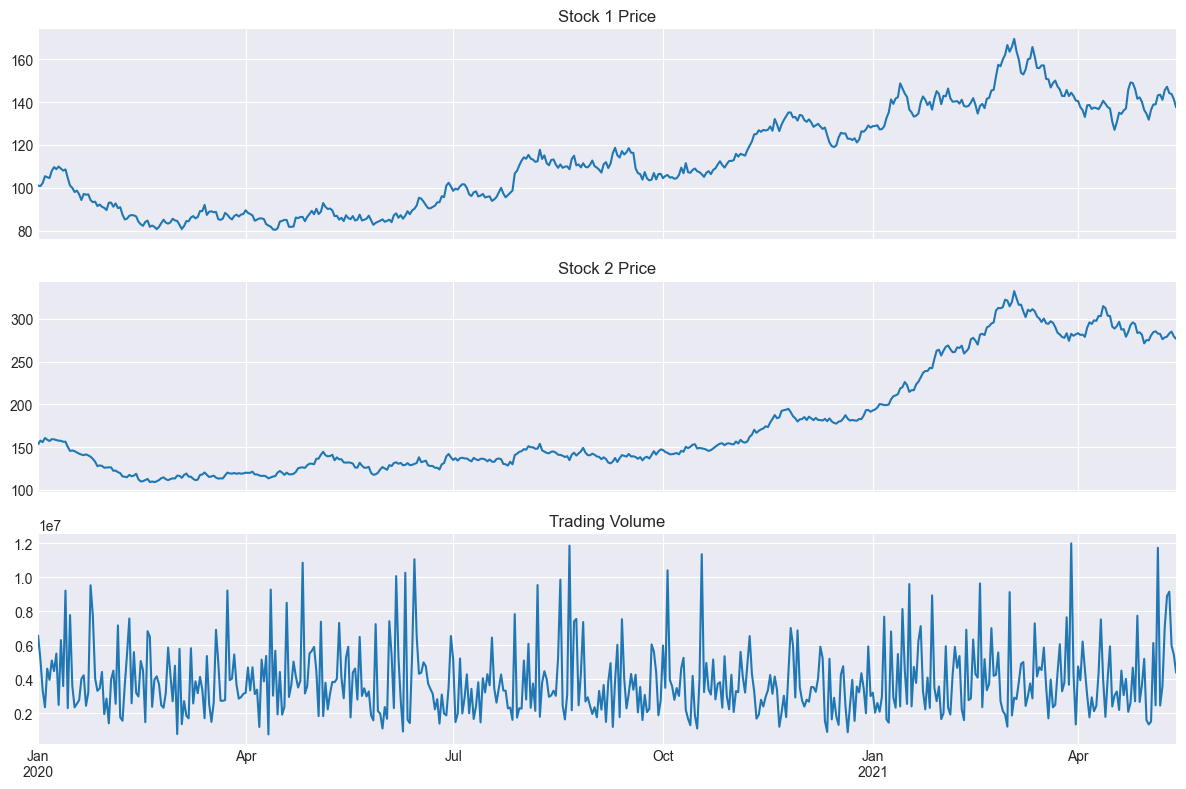

In [9]:
# Create synthetic multivariate financial time series
np.random.seed(42)
dates = pd.date_range(start='2020-01-01', periods=500, freq='D')

# Simulate stock prices with correlation
returns_stock1 = np.random.normal(0.0005, 0.02, 500)
returns_stock2 = 0.7 * returns_stock1 + np.random.normal(0.0003, 0.015, 500)
volume = np.random.lognormal(15, 0.5, 500)

price_stock1 = 100 * np.exp(np.cumsum(returns_stock1))
price_stock2 = 150 * np.exp(np.cumsum(returns_stock2))

# Create DataFrame
df = pd.DataFrame({
    'Stock1_Price': price_stock1,
    'Stock2_Price': price_stock2,
    'Volume': volume
}, index=dates)

print(df.head())

# Visualize
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
df['Stock1_Price'].plot(ax=axes[0], title='Stock 1 Price')
df['Stock2_Price'].plot(ax=axes[1], title='Stock 2 Price')
df['Volume'].plot(ax=axes[2], title='Trading Volume')
plt.tight_layout()
plt.show()

### 2.2 VAR (Vector Autoregression) Model

In [10]:
from sktime.forecasting.var import VAR

# Train-test split
train_size = int(0.8 * len(df))
df_train = df.iloc[:train_size]
df_test = df.iloc[train_size:]

# Fit VAR model
forecaster_var = VAR(maxlags=5)
forecaster_var.fit(df_train)

# Forecast
fh_multi = ForecastingHorizon(df_test.index, is_relative=False)
y_pred_var = forecaster_var.predict(fh=fh_multi)

print("VAR Forecast:")
print(y_pred_var.head())

VAR Forecast:
            Stock1_Price  Stock2_Price        Volume
2021-02-04    147.550810    271.455052  3.948820e+06
2021-02-05    148.078969    273.532241  3.974008e+06
2021-02-06    149.421012    276.353558  4.663253e+06
2021-02-07    149.816670    278.820084  4.067435e+06
2021-02-08    150.679223    281.198608  4.097423e+06


### 2.3 Visualize Multivariate Forecasts

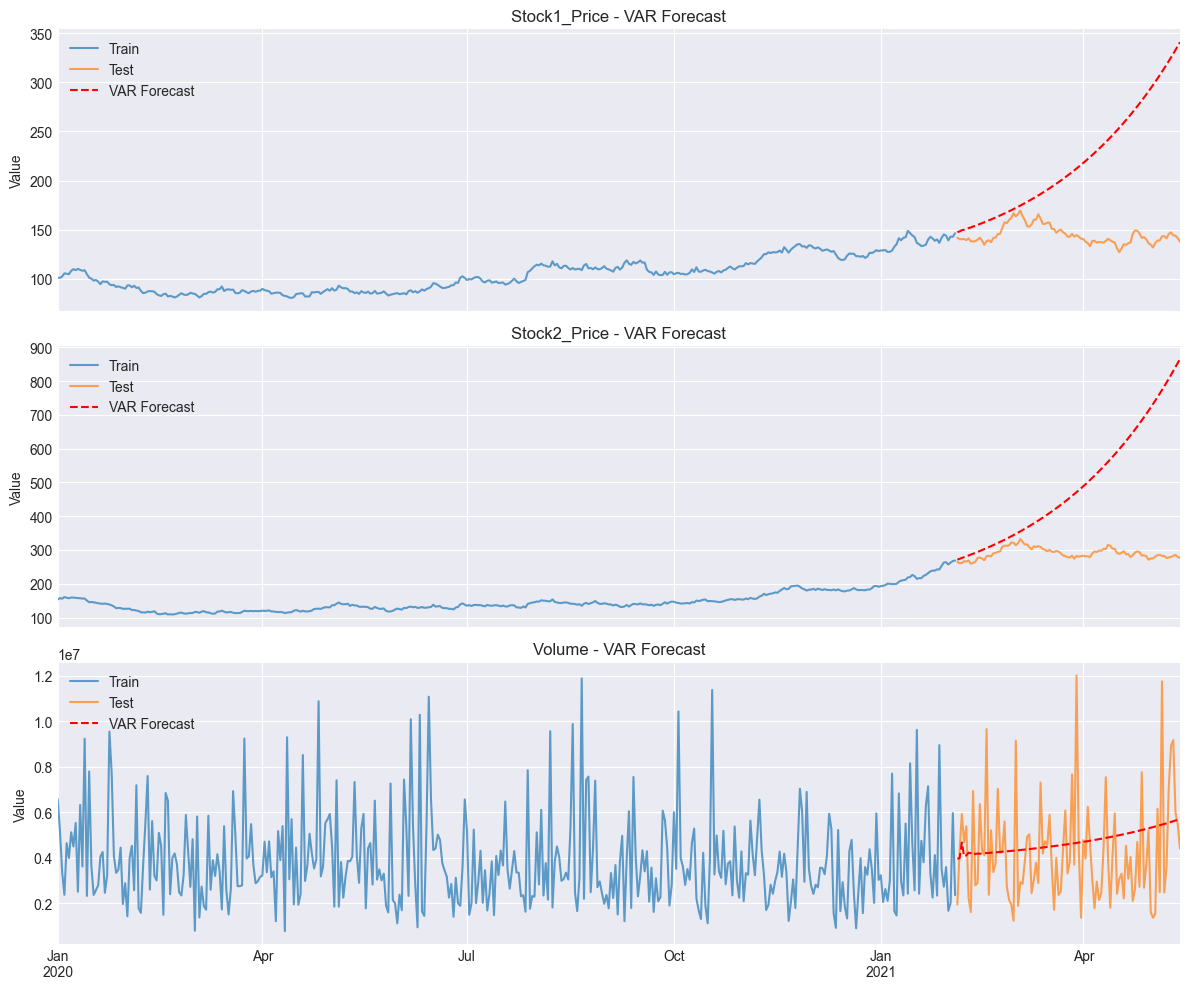

In [11]:
# Plot forecasts for each variable
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

for i, col in enumerate(df.columns):
    df_train[col].plot(ax=axes[i], label='Train', alpha=0.7)
    df_test[col].plot(ax=axes[i], label='Test', alpha=0.7)
    y_pred_var[col].plot(ax=axes[i], label='VAR Forecast', linestyle='--', color='red')
    axes[i].set_title(f'{col} - VAR Forecast')
    axes[i].legend()
    axes[i].set_ylabel('Value')

plt.tight_layout()
plt.show()

### 2.4 Feature Engineering with Transformers

In [12]:
from sktime.transformations.series.difference import Differencer
from sktime.transformations.series.lag import Lag
from sktime.forecasting.compose import TransformedTargetForecaster

# Create pipeline with differencing
forecaster_pipeline = TransformedTargetForecaster([
    ("differencer", Differencer(lags=1)),
    ("forecaster", VAR(maxlags=5))
])

forecaster_pipeline.fit(df_train)
y_pred_pipeline = forecaster_pipeline.predict(fh=fh_multi)

print("\nPipeline Forecast with Differencing:")
print(y_pred_pipeline.head())


Pipeline Forecast with Differencing:
            Stock1_Price  Stock2_Price        Volume
2021-02-04    146.603399    269.523584  3.011443e+06
2021-02-05    146.499592    269.878208  3.266973e+06
2021-02-06    146.890466    270.587910  3.805566e+06
2021-02-07    146.319367    271.042144  3.242673e+06
2021-02-08    146.655639    271.162441  3.438948e+06


### 2.5 Multivariate Evaluation

In [13]:
# Calculate metrics for each variable
results_multi = []

for col in df.columns:
    mape_var = mean_absolute_percentage_error(df_test[col], y_pred_var[col])
    mape_pipe = mean_absolute_percentage_error(df_test[col], y_pred_pipeline[col])
    
    rmse_var = np.sqrt(mean_squared_error(df_test[col], y_pred_var[col]))
    rmse_pipe = np.sqrt(mean_squared_error(df_test[col], y_pred_pipeline[col]))
    
    results_multi.append({
        'Variable': col,
        'VAR_MAPE': mape_var,
        'Pipeline_MAPE': mape_pipe,
        'VAR_RMSE': rmse_var,
        'Pipeline_RMSE': rmse_pipe
    })

results_multi_df = pd.DataFrame(results_multi)
print("\nMultivariate Forecasting Results:")
print(results_multi_df.to_string(index=False))


Multivariate Forecasting Results:
    Variable  VAR_MAPE  Pipeline_MAPE     VAR_RMSE  Pipeline_RMSE
Stock1_Price  0.526103       0.078504 9.484860e+01   1.253207e+01
Stock2_Price  0.699876       0.049692 2.647644e+02   1.921394e+01
      Volume  0.589613       0.398187 2.237838e+06   2.394171e+06


### 2.6 Advanced: Exogenous Variables

/Users/dush/Code/cst4150/06-Time-Series/03a sktime/sktime/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


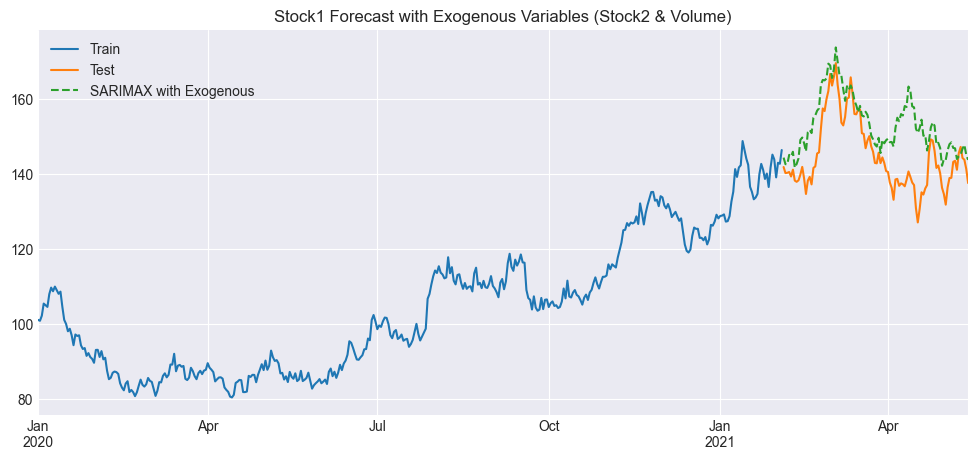


SARIMAX with Exogenous MAPE: 0.0599


In [14]:
from sktime.forecasting.sarimax import SARIMAX

# Use Stock2 and Volume as exogenous variables to forecast Stock1
y_train_stock1 = df_train['Stock1_Price']
y_test_stock1 = df_test['Stock1_Price']

X_train = df_train[['Stock2_Price', 'Volume']]
X_test = df_test[['Stock2_Price', 'Volume']]

# SARIMAX with exogenous variables
forecaster_sarimax = SARIMAX(order=(1, 1, 1), seasonal_order=(0, 0, 0, 0))
forecaster_sarimax.fit(y_train_stock1, X=X_train)
y_pred_sarimax = forecaster_sarimax.predict(fh=fh_multi, X=X_test)

# Plot
fig, ax = plt.subplots(figsize=(12, 5))
y_train_stock1.plot(ax=ax, label='Train')
y_test_stock1.plot(ax=ax, label='Test')
y_pred_sarimax.plot(ax=ax, label='SARIMAX with Exogenous', linestyle='--')
plt.legend()
plt.title('Stock1 Forecast with Exogenous Variables (Stock2 & Volume)')
plt.show()

mape_sarimax = mean_absolute_percentage_error(y_test_stock1, y_pred_sarimax)
print(f"\nSARIMAX with Exogenous MAPE: {mape_sarimax:.4f}")